In [ ]:
#Importing relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import sklearn.cluster as cluster
from sklearn.cluster import KMeans
%matplotlib inline
from scipy.stats import linregress
import plotly.graph_objects as go
import tabulate as tabulate

In [ ]:
#Uploading our dataset in our environment


In [ ]:
#Assigning a variable to our dataset
Onlretail = pd.read_excel('Online Retail.xlsx')

In [ ]:
#getting an overview of our data
Onlretail.head(25)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
#getting to know the structure of the data
Onlretail.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
#getting to know the number of rows and columns in my data
Onlretail.shape

(541909, 8)

In [ ]:
##getting the number of rows
Onlretail.shape[0]

541909

In [ ]:
#getting the number of colums(1)
Onlretail.shape[1]

8

In [ ]:
#getting the summary statistics of the  qualitative data in my dataset
Onlretail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
#checking for missing values
Onlretail.isna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
541904,False,False,False,False,False,False,False,False
541905,False,False,False,False,False,False,False,False
541906,False,False,False,False,False,False,False,False
541907,False,False,False,False,False,False,False,False


In [ ]:
##checking the count of missing values
Onlretail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Looking at this output, the missing values are huge , so we drop them to avoid making a bias conclusions and inferences.

In [ ]:
#dropping the rows with missing values in the description column
Onlretail.dropna(subset=['Description'], inplace=True)

In [ ]:
#droping the rows with missing values in the Customer ID column
Onlretail.dropna(subset=['CustomerID'], inplace=True)

In [ ]:
#checking if missing values have been dropped
Onlretail.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
#checking if missing values in Description and  Customer ID have been dropped
Onlretail.head(25)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
#checking for duplicates
Onlretail.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
541904,False
541905,False
541906,False
541907,False


In [ ]:
#deleting duplicates
Onlretail.drop_duplicates(inplace=True)

In [ ]:
#checking for the duplicates count
Onlretail.duplicated().sum()

np.int64(0)

In [ ]:
#checking for the number of data after dropping duplicates
Onlretail.shape

(401604, 8)

In [ ]:
#checking for the unique value in each column
Onlretail.nunique()

,0
InvoiceNo,22190
StockCode,3684
Description,3896
Quantity,436
InvoiceDate,20460
UnitPrice,620
CustomerID,4372
Country,37


In [ ]:
#checking for the names of the countries present in the dataset
Onlretail['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [ ]:
#outputing categorical datatypes in the dataset
Onlretail.select_dtypes(include='object')


,InvoiceNo,StockCode,Description,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,536365,71053,WHITE METAL LANTERN,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom
...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,France


While 'InvoiceNo' might appear to be numerical, it's crucial to consider its nature and how it's used within the dataset. Based on the code provided and common practices in retail data analysis, 'InvoiceNo' is likely a categorical variable, even if it contains numbers.
Here's the reasoning:

Unique Identifier: 'InvoiceNo' is likely used as a unique identifier for each transaction or order. Each invoice would have a distinct InvoiceNo, even if those numbers are sequential.

Not for Numerical Calculations: You wouldn't perform mathematical calculations on 'InvoiceNo' like you would with numerical variables (e.g., quantity, price). It doesn't make sense to find the average or sum of invoice numbers.

Representing Groups: 'InvoiceNo' acts more as a label or category to group items within the same transaction. All items belonging to the same invoice would share the same 'InvoiceNo'.

Data Type: While the provided code doesn't explicitly reveal the data type of 'InvoiceNo', if it's stored as an 'object' in the Pandas DataFrame (as revealed by df.select_dtypes(include='object')), it further suggests its categorical nature.

In [ ]:
#output quantity and invoice date
Onlretail[['Quantity', 'InvoiceDate']]

,Quantity,InvoiceDate
0,6,2010-12-01 08:26:00
1,6,2010-12-01 08:26:00
2,8,2010-12-01 08:26:00
3,6,2010-12-01 08:26:00
4,6,2010-12-01 08:26:00
...,...,...
541904,12,2011-12-09 12:50:00
541905,6,2011-12-09 12:50:00
541906,4,2011-12-09 12:50:00
541907,4,2011-12-09 12:50:00


In [ ]:
#outputting transactions starting with C
Onlretail[Onlretail['InvoiceNo'].str.startswith('C', na=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
#Outputing transactions that start with C
Onlretail[Onlretail['InvoiceNo'].str.startswith('C', na=False)].shape

(8872, 8)

In [ ]:
#assign a variable to the cancelled transaction called C
C = Onlretail[Onlretail['InvoiceNo'].str.startswith('C', na=False)]

In [ ]:
C.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,8872.000000,8872,8872.000000,8872.000000
mean,-30.774910,2011-06-27 09:06:05.024797184,18.899512,14990.152953
min,-80995.000000,2010-12-01 09:41:00,0.010000,12346.000000
25%,-6.000000,2011-03-23 11:23:45,1.450000,13505.000000
50%,-2.000000,2011-07-11 13:51:00,2.950000,14868.000000
75%,-1.000000,2011-10-06 20:36:00,4.950000,16393.000000
max,-1.000000,2011-12-09 11:58:00,38970.000000,18282.000000
std,1172.249902,NaN,445.190864,1708.230387


In [ ]:
#finding the percentage of C
C.shape[0] / Onlretail.shape[0] * 100

2.209141343213713

From the entire data, only about 2.20 was cancelled

In [ ]:
#doing a unique function on stock code
Onlretail['StockCode'].nunique()

3684

In [ ]:
#output the unique characters in stockcode
Onlretail['StockCode'].unique()

array(['85123A', 71053, '84406B', ..., '90214Z', 90089, 23843],
      dtype=object)

In [ ]:
#output the description for the 85123A in the stockcode
Onlretail[Onlretail['StockCode'] == '85123A']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:02:00,2.55,17850.0,United Kingdom
66,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:32:00,2.55,17850.0,United Kingdom
220,536390,85123A,WHITE HANGING HEART T-LIGHT HOLDER,64,2010-12-01 10:19:00,2.55,17511.0,United Kingdom
262,536394,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,2010-12-01 10:39:00,2.55,13408.0,United Kingdom
...,...,...,...,...,...,...,...,...
538708,581412,85123A,CREAM HANGING HEART T-LIGHT HOLDER,4,2011-12-08 14:38:00,2.95,14415.0,United Kingdom
539083,581432,85123A,CREAM HANGING HEART T-LIGHT HOLDER,32,2011-12-08 15:51:00,2.55,13798.0,United Kingdom
539979,581452,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,2011-12-08 18:03:00,2.55,17675.0,United Kingdom
540217,581472,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2011-12-08 19:55:00,2.95,15796.0,United Kingdom


In [ ]:
#finding the stock code with the highest quantity
Onlretail['StockCode'].value_counts().head(1)


,count
StockCode,
85123A,2065


In [ ]:
#finding the name of the product with highest quantity
Onlretail[Onlretail['StockCode'] == '85123A'].head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom


From the stockcode,the product with the highest quantity is the White Hanging Heart T-Light Holder with the stockcode of 85123A.
I would advice that the company invest more into the marketing of the white hanging heart t-light holder as they will gain more profit and return on investment of that particular holder.
They can also run some  promotions or maybe do a bundled product (add some other products that are not realy selling to it at a relatively cheaper price) to boost more revenue for the company.



In [ ]:
#outputting post
Onlretail[Onlretail['StockCode'] == 'POST'].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00,18.0,12583.0,France
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00,15.0,12791.0,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00,18.0,12662.0,Germany
5073,536840,POST,POSTAGE,1,2010-12-02 18:27:00,18.0,12738.0,Germany
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00,18.0,12686.0,France


In [ ]:
#finding the unique stockcodes
Onlretail['StockCode'].unique()

array(['85123A', 71053, '84406B', ..., '90214Z', 90089, 23843],
      dtype=object)

In [ ]:
#Finding the percentage frequency of the first 10 stockcode with the highest quantity
top_10_stockcode = Onlretail['StockCode'].value_counts(normalize=True).head(10)*100
top_10_stockcode

,proportion
StockCode,
85123A,0.514188
22423,0.471609
85099B,0.413093
47566,0.350843
84879,0.349847
20725,0.335156
22720,0.304778
POST,0.297806
22197,0.276392


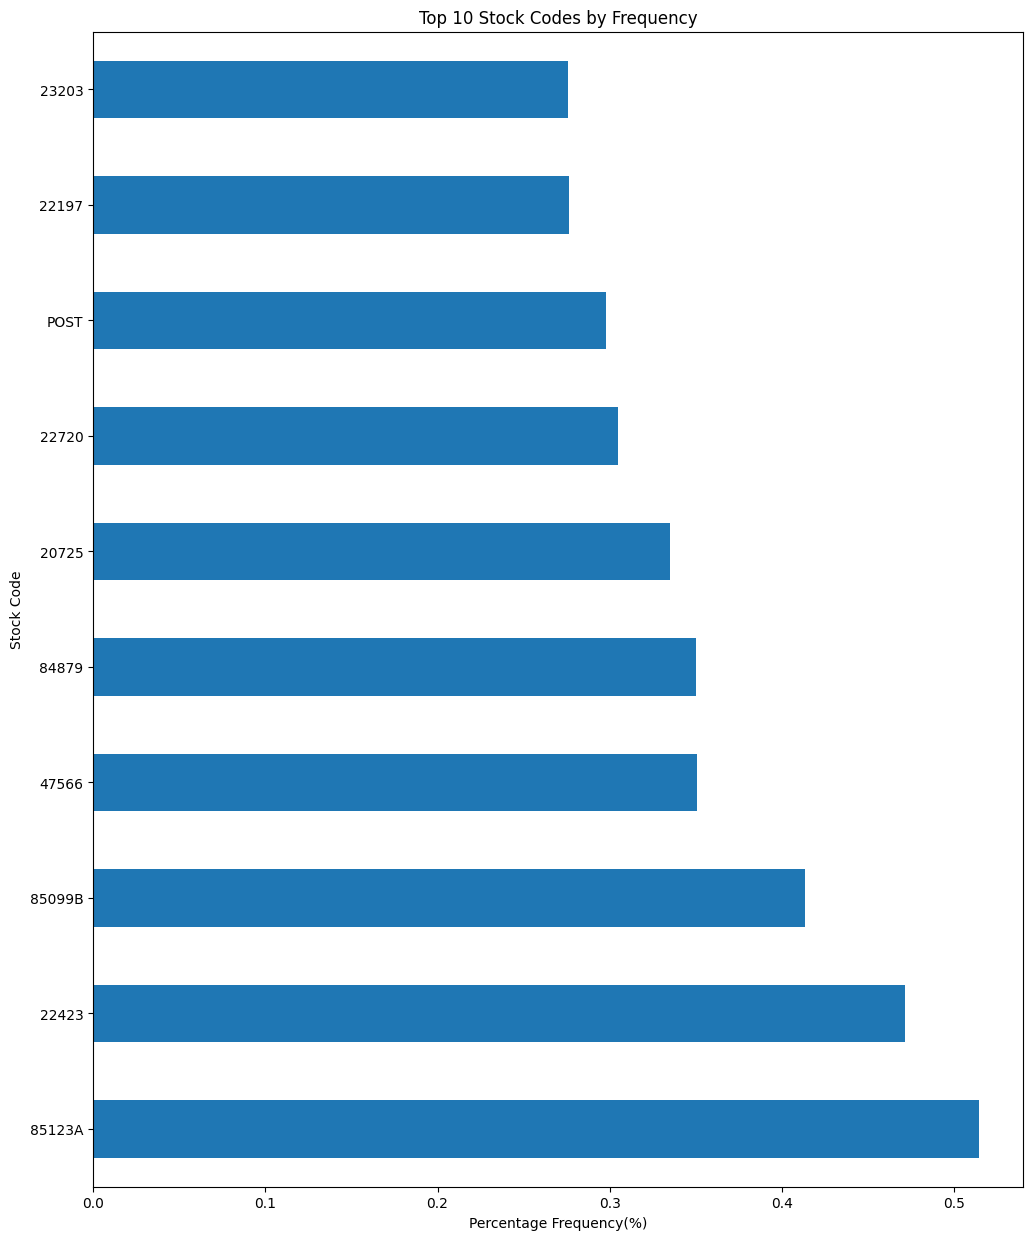

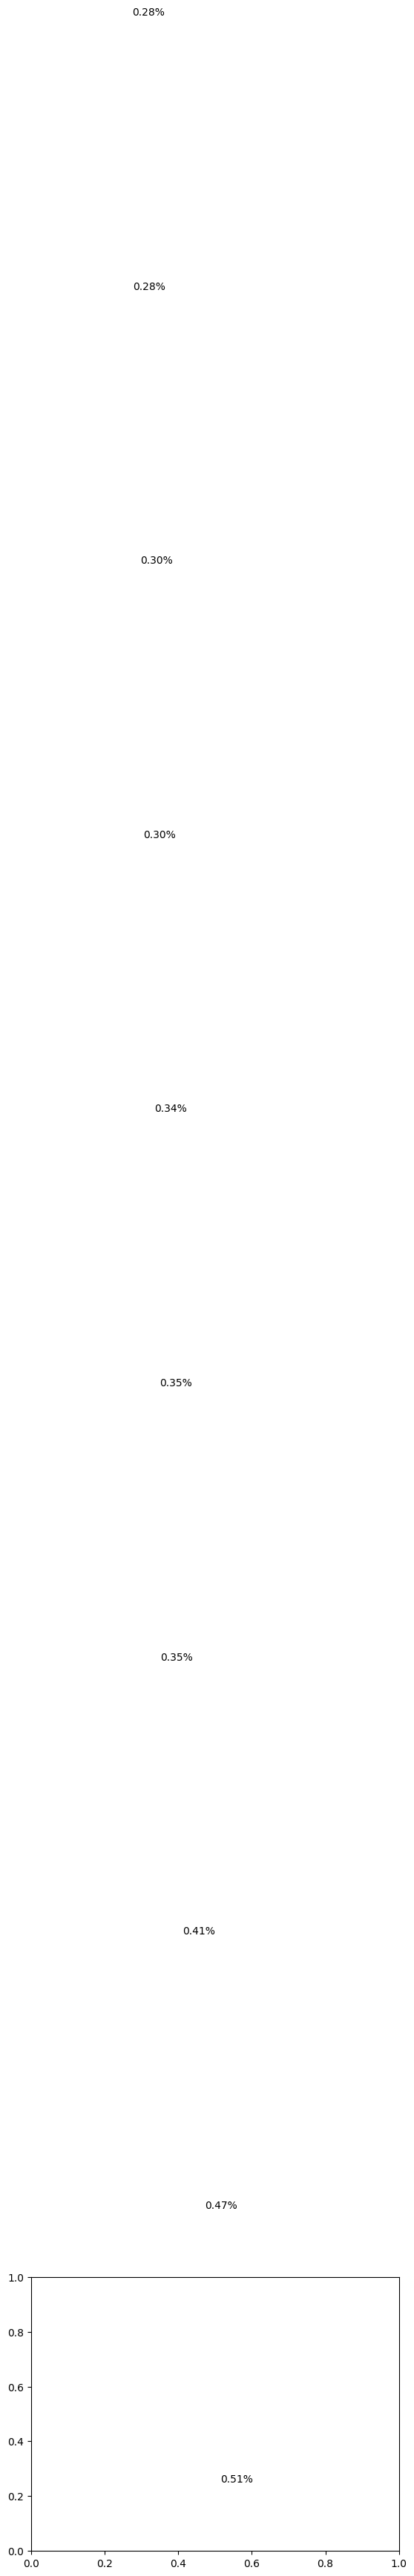

In [ ]:
#finding the percentage frequency of the first 10 stockcode with the highest quantity
top_10_stockcode = Onlretail['StockCode'].value_counts(normalize=True).head(10) * 100

#visualization
plt.figure(figsize=(12, 15))
top_10_stockcode.plot(kind='barh')
plt.title('Top 10 Stock Codes by Frequency')
plt.xlabel('Percentage Frequency(%)')
plt.ylabel('Stock Code')
plt.gca().invert_yaxis
plt.show()

#frequencies to the graph
for index,value in enumerate(top_10_stockcode.values):
  plt.text(value,index+0.25,f'{value:.2f}%',fontsize=10)

In [ ]:
#finding the frequency of the first 10 stock code with the highest quantity
Onlretail['StockCode'].value_counts().head(10)

,count
StockCode,
85123A,2065
22423,1894
85099B,1659
47566,1409
84879,1405
20725,1346
22720,1224
POST,1196
22197,1110


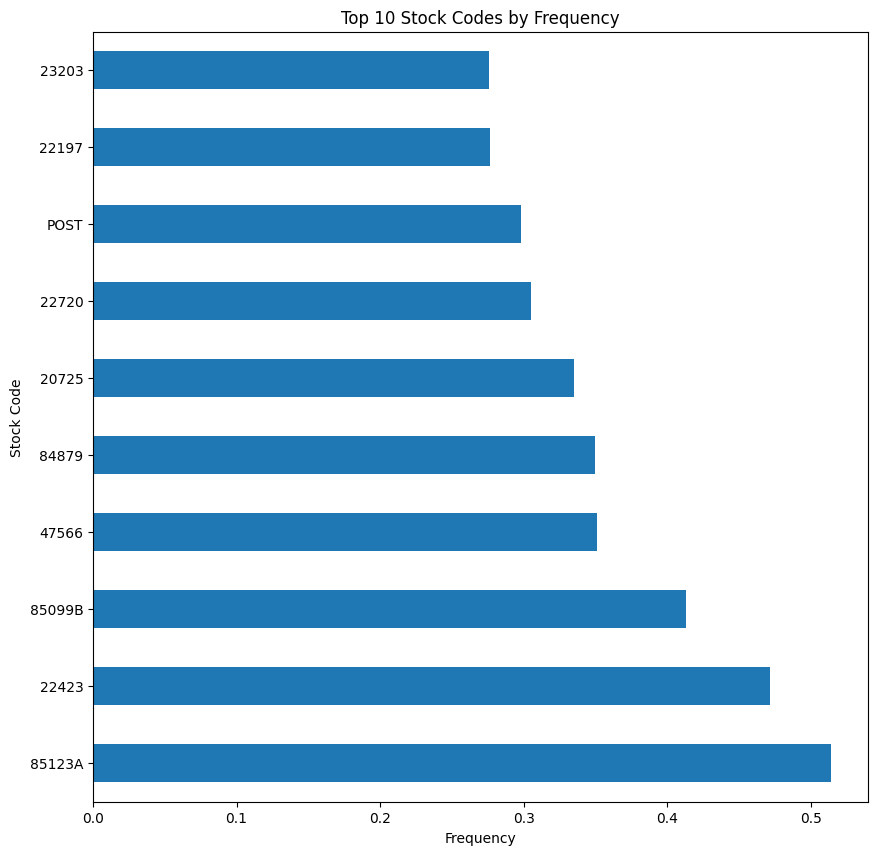

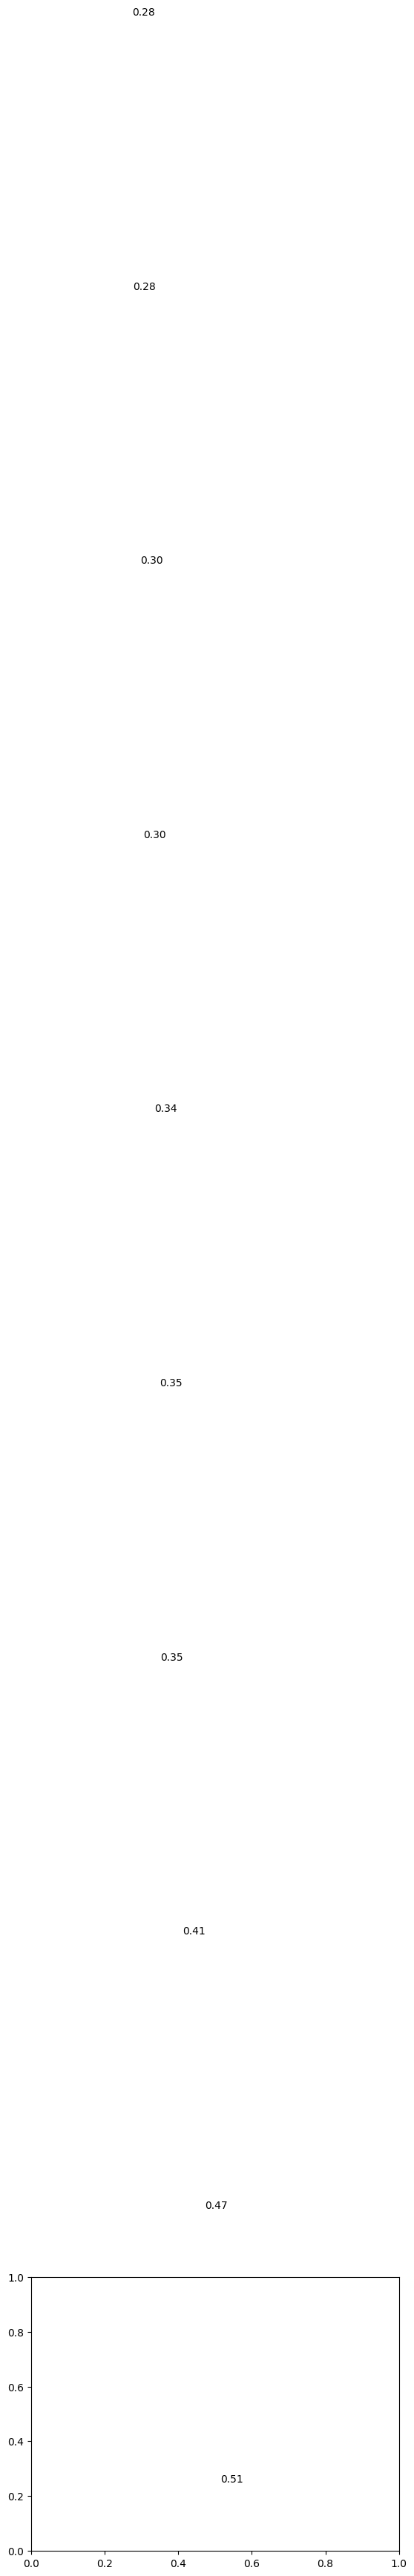

In [ ]:
#finding the frequency of the first 10 stock code with the highest quantity
Onlretail['StockCode'].value_counts().head(10)

#visualization
plt.figure(figsize=(10, 10))
top_10_stockcode.plot(kind='barh')
plt.title('Top 10 Stock Codes by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Stock Code')
plt.gca().invert_yaxis
plt.show()

#frequencies to the graph
for index,value in enumerate(top_10_stockcode.values):
  plt.text(value,index+0.25,f'{value:.2f}',fontsize=10)

In [ ]:
#finding the number of countries in the dataset
Onlretail['Country'].nunique()

37

In [ ]:
#finding unique countries
Onlretail['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [ ]:
#finding the frequency of all countries
Onlretail['Country'].value_counts()

,count
Country,
United Kingdom,356728
Germany,9480
France,8475
EIRE,7475
Spain,2528
Netherlands,2371
Belgium,2069
Switzerland,1877
Portugal,1471


In [ ]:
#finding popular products in each country
Onlretail.groupby('Country')['StockCode'].value_counts()

Country      StockCode
Australia    22720        10
             20725         9
             21731         9
             22090         8
             22138         8
                          ..
Unspecified  85049A        1
             85179A        1
             85179C        1
             85180A        1
             85180B        1
Name: count, Length: 18981, dtype: int64

In [ ]:
 #finding the count of unspecified
 Onlretail[Onlretail['Country'] == 'Unspecified']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
152712,549687,20685,DOORMAT RED RETROSPOT,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified
152713,549687,22691,DOORMAT WELCOME SUNRISE,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified
152714,549687,48116,DOORMAT MULTICOLOUR STRIPE,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified
152715,549687,21213,PACK OF 72 SKULL CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.0,Unspecified
152716,549687,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.0,Unspecified
...,...,...,...,...,...,...,...,...
308810,564051,23007,SPACEBOY BABY GIFT SET,1,2011-08-22 13:32:00,16.95,14265.0,Unspecified
308811,564051,21833,CAMOUFLAGE LED TORCH,12,2011-08-22 13:32:00,1.69,14265.0,Unspecified
308812,564051,23081,GREEN METAL BOX ARMY SUPPLIES,2,2011-08-22 13:32:00,8.25,14265.0,Unspecified
308813,564051,23046,PAPER LANTERN 9 POINT DELUXE STAR,2,2011-08-22 13:32:00,6.65,14265.0,Unspecified


In [ ]:
#finding all product description in unspecified
Onlretail[Onlretail['Country'] == 'Unspecified']['Description'].nunique()

213

In [ ]:
#finding the list stockcode in unspecified
Onlretail[Onlretail['Country'] == 'Unspecified']['StockCode'].unique()

array([20685, 22691, 48116, 21213, 21977, 21976, 21212, 84992, 84991,
       21974, 21973, 21211, 21124, 21122, 21123, 21121, 22953, 23078,
       22619, 21888, 21890, 22620, 21891, 21705, 21704, 21703, 22621,
       22150, 23127, 23126, 20972, 22149, 22752, 22758, 22754, 22584,
       22585, 22815, '16161U', 22707, 22711, 22985, 22048, 22986, 23233,
       23232, 22653, 22652, 22960, 22989, 22993, 22924, 23159, 21908,
       82582, 22413, 21907, 71459, 22485, 82482, 84879, 21497, 23231,
       23122, 23119, 23108, 23240, 23237, 23239, 23245, 22627, 22625,
       '16161P', 21499, 21500, 21503, 22047, 22051, 22050, 22709, 40001,
       21628, '46000S', '46000M', 22423, '47563A', 23124, '47574A', 35968,
       '84559A', 21586, 21733, 23268, 23210, 22449, 20886, 21588,
       '47599B', 22846, 23336, 23338, 23339, 21033, 20679, 22046, 23546,
       21108, 21002, 85212, 21770, 22750, 84050, 84813, 23079, 23014,
       85213, 23068, 22139, '84912B', 22727, '84559B', 84549, 22840,
       2260

In [ ]:
#outputing first 20 dates
Onlretail['InvoiceDate'].head(50)

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00
5,2010-12-01 08:26:00
6,2010-12-01 08:26:00
7,2010-12-01 08:28:00
8,2010-12-01 08:28:00
9,2010-12-01 08:34:00
